In [1]:
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math
from ipysigma import Sigma


In [2]:
## Carga datos 
import polars.selectors as cs 

def load_pivot_data( 
    fp : str 
    ) -> pl.DataFrame:

    # Carga datos
    df = pl.read_csv(fp)

    ### Unpivot dataframes
    df = df.with_columns(
        pl.col("rama").cast(pl.String)
    ).unpivot(
        cs.numeric(), index="rama"
    ).rename(
        {
            "value" : "weight"
        }
    ).filter(
        (pl.col("weight")>0) &
        (pl.col("weight")!=1)
    )

    return df.to_pandas()
    
## Población Ocupada 2023
df_pot = load_pivot_data("datos/proximity_matrices/pot/proximity_matrix_pot23.csv")
## Unidades Económicas 2023
df_ue = load_pivot_data("datos/proximity_matrices/ue/proximity_matrix_ue23.csv")
## Valor Agregado 2023
df_vacb = load_pivot_data("datos/proximity_matrices/vacb/proximity_matrix_vacb23.csv")

## Visualizing the Product Space

To visualize the product space we use some simple design criteria. First, we want the visualization of the product space to be a connected network. By this, we mean avoiding islands of isolated products. The second criterion is that we
want the network visualization to be relatively sparse. Trying to visualize too many links can create unnecessary visual complexity where the most relevant connections will be occluded. This is achieved by creating a visualization in which the average number of links per node is not larger than 5 and results in a representation that can summarize the structure of the product space using
the strongest 1% of the links

To make sure the visualization of the product space is connected, we calculate the maximum spanning tree (MST) of the proximity matrix. MST is the set of links that connects all the nodes in the network using a minimum number of connections and the maximum possible sum of proximities. We calculated the MST using Kruskal’s algorithm. Basically the algorithm sorts the values of the
proximity matrix in descending order and then includes links in the MST if and only if they connect an isolated product. By definition, the MST includes all products, but the number of links is the minimum possible.

The second step is to add the strongest connections that were not selected for the MST. In this visualization we included the first 1,006 connections satisfying our criterion. By definition a spanning tree for 774 nodes contains 773
edges. With the additional 1,006 connections we end up with 1,779 edges and an average degree of nearly 4.6.

After selecting the links using the above mentioned criteria we build a visualization using a force-directed layout algorithm. In this algorithm nodes repel each other, just like electric charges, while edges act as spring trying to bring connected nodes together. This helps to create a visualization in which densely connected sets of nodes are put together while nodes that are not connected are pushed apart.

Finally, we manually clean up the layout to minimize edge crossings and provide the most clearly representation possible.

In [49]:
## Crea gráficas con NetworkX
G_pot = nx.from_pandas_edgelist(
    df_vacb,
    source='rama', 
    target='variable', 
    edge_attr=['weight']
)

## Construye Maximum Spanning Tree
mst = nx.maximum_spanning_tree(G_pot)

# Displaying the graph with a size mapped on degree and
# a color mapped on a categorical attribute of the nodes
Sigma(mst, node_color='category')

Sigma(nx.Graph with 261 nodes and 260 edges)

## Exponential Random Graph 

Para lograr crear una visualización en la que el grado promedio por nodo sea alrededor de 6 y resulte en una representación que pueda resumir la estructura del espacio producto usando el 1% de los links más fuertes, usamos el método de Monte Carlo via Cadenas de Markov en Gráficas Aleatorias Exponenciales para rediseñar la red para que tenga las promiedad de grado promedio que necesitamos, la propiedad observable que desearíamos tener. 
 

In [50]:
# Multiplicador de Lagrange que define el número promedio de enlaces
θ = 5.0

# Edges candidatas a ser conectadas
candidatas = [(i,j) for i,j in df_pot.query("weight!=1 and (weight < 0.65 and weight>0.35 )")[["rama", "variable"]].to_records(index = False)]


In [51]:
def erg_mcmc(G : nx.Graph, 
             θ : float, 
             iteraciones : int, 
             edges_candidatas : list) -> nx.Graph:

    G_erg = G.copy()
    
    # Lista que monitorea el cambio en los enlaces promedio por nodo
    promedio_enlaces = []

    # Comenzamos el algoritmo
    for it in range(iteraciones):
    
        # Compute RM
        if it % 10000 == 0:
            print(f"It: {it}")
            
        candidatas_ids = list(range(len(edges_candidatas)))
        candidatas_ids
    
        candidato_id = np.random.choice(candidatas_ids)
        
        edge = candidatas[candidato_id]
    
        i,j = edge
        
        if G_erg.has_edge(i,j):
            δ = -1
        else:
            δ = 1
        
        # Verificamos si el cambio es aceptado
        r = np.random.uniform(0,1) 
        
        if r <= math.exp(-θ * δ):
            if δ == -1:
                pass
            else:
                G_erg.add_edge(i,j)
                
        ## Monitoreamos cantidad promedio de edges
        # Calculate the sum of degrees
        sum_of_degrees = sum(dict(G_erg.degree()).values())
        
        # Get the number of nodes
        num_nodes = G_erg.number_of_nodes()
        
        # Calculate the global average degree
        global_average_degree = sum_of_degrees / num_nodes
        
        promedio_enlaces.append(global_average_degree)
        

    ## Grafiquemos el grado promedio por nodo de cada iteración
    plt.plot(promedio_enlaces)
    plt.xlabel("Iteración")
    plt.ylabel("Average number of links per node")

    return G_erg

It: 0
It: 10000
It: 20000
It: 30000
It: 40000
It: 50000
It: 60000
It: 70000
It: 80000
It: 90000


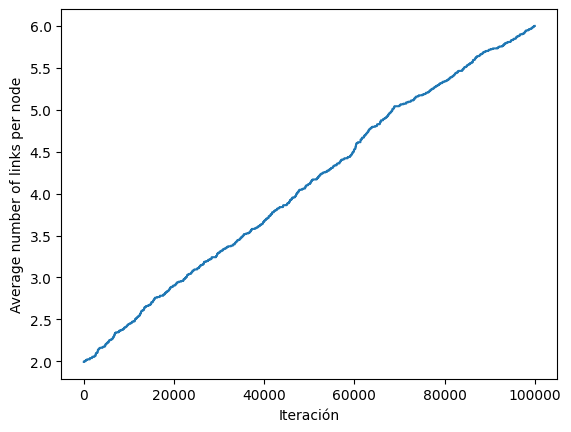

In [52]:
mst_erg = erg_mcmc(mst, θ, 100_000, candidatas)


In [53]:
# Displaying the graph with a size mapped on degree and
# a color mapped on a categorical attribute of the nodes
Sigma(mst_erg, node_color='category')

Sigma(nx.Graph with 261 nodes and 783 edges)

## Exportamos las redes rediseñadas en formato .graphml para obtener el layout ForceAtlas en Gephi

In [54]:
### Export to GraphML
nx.write_graphml(mst_erg, "mst_erg.graphml")


## Cargamos las redes con el layout ForceAtlas para rotarlo

In [55]:
# Importing a gexf graph
mst_erg_force_atlas = nx.read_gml('output/mst_erg_force_atlas/mst_erg_force_atlas.gml')


In [56]:
## Verificamos el layout de Gephi
def grafica_force_atlas(
        G : nx.Graph,
        var_name : str
    ) -> None:

    new_pos = {node : np.array([G.nodes[node]["graphics"]["x"], G.nodes[node]["graphics"]["y"] ])for node in G.nodes  }
    # Draw the graph
    nx.draw(G, new_pos, with_labels=True, node_color='skyblue', node_size=100, font_size=5)
    plt.title(f"Force-Directed Layout {var_name}")
    plt.show()

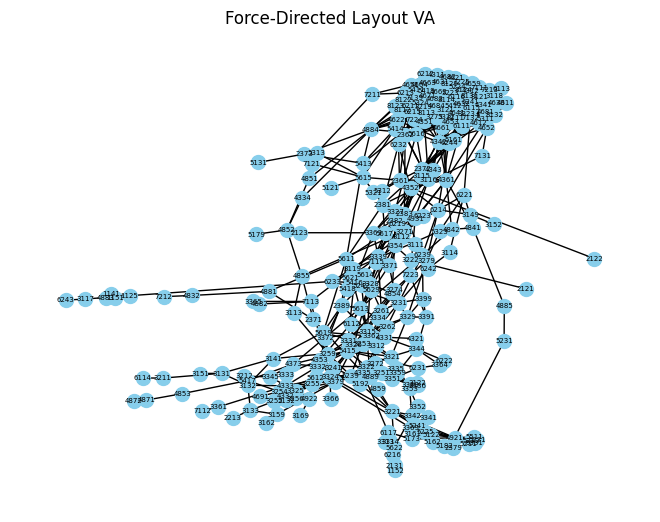

In [57]:
grafica_force_atlas(mst_erg_force_atlas, "VA")

## Rotamos la red hasta tener la representación que necesitamos

In [58]:
def nuevo_vector(punto : np.array, 
                 theta : float
    ) -> np.array:
    vector_rotado = np.array(
        [
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)] 
        ]
    ) @  punto
    
    return vector_rotado

def rotacion(
    G : nx.Graph,
    grados : float,
    var_name : str
    ) -> dict:

    new_pos = {node : np.array([G.nodes[node]["graphics"]["x"], G.nodes[node]["graphics"]["y"] ])for node in G.nodes  }

    x_min = min(np.array([i for i in new_pos.values()])[:,0])
    y_min = min(np.array([i for i in new_pos.values()])[:,1])
    
    pos_positivos = {rama : point - np.array([x_min, y_min]) for rama, point in new_pos.items()}

    pos_rotada = {rama : list(nuevo_vector(point, grados)) for rama, point in pos_positivos.items()}
    
    # Draw the graph
    nx.draw(G, pos_rotada, with_labels=True, node_color='skyblue', node_size=100, font_size=5)
    plt.title(f"Force-Directed Layout {var_name}")
    plt.show()

    return pos_rotada


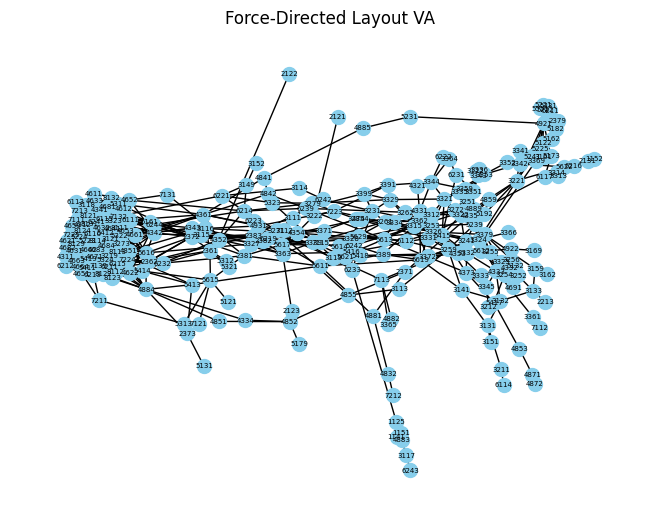

In [67]:
#pos_rotada = rotacion(mst_erg_force_atlas, 69.9, "POT")
pos_rotada = rotacion(mst_erg_force_atlas, 64.6, "VA")


## Agregamos los sectores a los que pertenecen los nodos


In [68]:
## Diccionario de sectores
sectores_scian = {
    ("11") : "Agricultura",
    ("21") : "Minería",
    ("22") : "Energía",
    ("23") : "Construcción",
    ("31", "32", "33") : "Manufactura",
    ("43") : "Comercio al por mayor",
    ("46") : "Comercio al por menor",
    ("48", "49") : "Transporte, Correos y Almacenamiento",
    ("51", "52", "53", "54", "55", "56", "61", "62", "71", "72", "81") : "Servicios",
    ("93") : "Actividades Gubernamentales",
}

sectores_scian = {
    ("11") : "Recursos naturales",
    ("21") : "Minería y Energía",
    ("22") : "Minería y Energía",
    ("23") : "Construcción",
    ("31", "32", "33") : "Manufactura",
    ("43", "46") : "Comercio",
    ("48", "49", "51") : "Transporte y Comunicaciones",
    ("52", "53") : "Servicios financieros y mobiliarios",
    ("54", "55", "56") : "Servicios profesionales y de apoyo",
    ("61", "62") : "Servicios educativos y de salud",
    ("71", "72") : "Hospedaje y esparcimiento",
    ("81", "93") : "Otros servicios",
}

### Agregamos el sector al que pertenece el nodo
sectores_nodos = {nodo : nombre_sector 
        for nodo in mst_erg.nodes 
        for id_sector,nombre_sector in sectores_scian.items() 
        if nodo[:2] in id_sector}

nx.set_node_attributes(mst_erg, sectores_nodos, "sector")

In [69]:
### Agregamos nombres de las ramas
ramas_nombres = pl.read_csv("datos/ramas_nombres/ramas_nombres.csv").unique()
ramas_nombres = ramas_nombres.with_columns(
    pl.col("rama_id").cast(pl.String)
)

ramas_nombres = {i:j for i,j in ramas_nombres.to_pandas().to_records(index = False)} 

### Agrega el atributo nombre
nx.set_node_attributes(mst_erg, ramas_nombres, "nombre")

In [70]:
### Export to GraphML
## Ajusta la posición para que esten en atributos x,y no en un arreglo de numpy

for node,(x,y) in pos_rotada.items():
    mst_erg.nodes[node]['x'] = float(x)
    mst_erg.nodes[node]['y'] = float(y)

nx.write_graphml(mst_erg, "output/mst_erg_force_atlas_rotado/mst_erg_force_atlas_rotado.graphml")